<a href="https://colab.research.google.com/github/kaustubh8salunkhe/quant-projects/blob/main/Momentum%20Options%20Pricer/12_1_Momentum_Factor_Backtester.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Set plotting style for professional portfolio visuals
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 12-1 Momentum Factor Backtester

**Methodology:**
This module backtests a classic "12-1 Momentum" anomaly across a highly liquid basket of National Stock Exchange of India (NSE) equities. The strategy ranks stocks based on their past 12-month returns, deliberately excluding the most recent 1-month to control for short-term mean reversion.

**Mechanics:**
The algorithm constructs an equally weighted, long-only portfolio of the top 3 momentum stocks, rebalancing monthly. Crucially, the model incorporates a realistic 10-basis-point (bps) transaction cost assumption per trade. Institutional portfolios decay rapidly under high turnover without strict cost accounting, making this constraint vital for accurate out-of-sample simulation.

/tmp/ipykernel_3108/235460291.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2019-01-01", end="2024-01-01")
[*******************   40%                       ]  4 of 10 completed

Fetching NSE equity data from 2019 to 2024...


[*********************100%***********************]  10 of 10 completed



Strategy Results (2019-2024):
Annualized Sharpe Ratio: 0.56
Maximum Drawdown: -26.03%



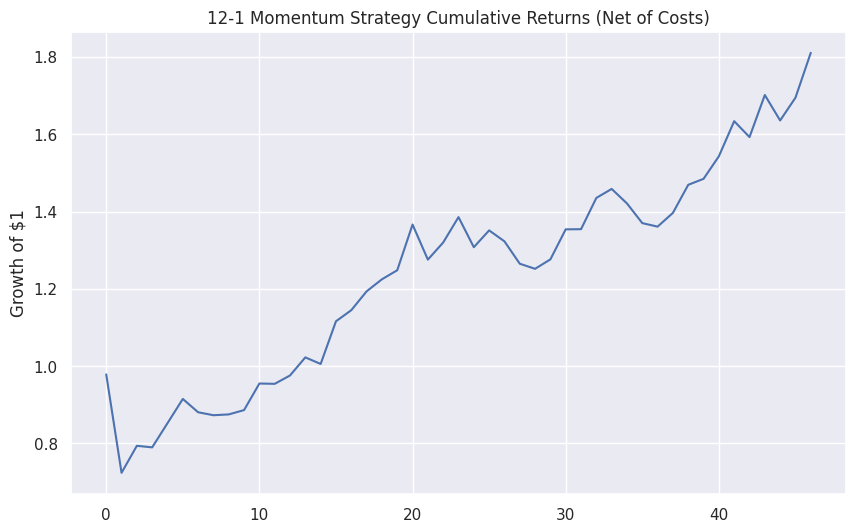

In [20]:
def run_momentum_backtest():
    # Define a basket of highly liquid NSE stocks
    tickers = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ICICIBANK.NS',
               'SBIN.NS', 'BHARTIARTL.NS', 'ITC.NS', 'LT.NS', 'HINDUNILVR.NS']

    print("Fetching NSE equity data from 2019 to 2024...")
    data = yf.download(tickers, start="2019-01-01", end="2024-01-01")
    # Correctly access 'Close' for all tickers from the MultiIndex columns, as it's now adjusted
    data = data.xs('Close', level=0, axis=1)

    # Resample to monthly data
    monthly_prices = data.resample('ME').last()

    # Calculate the 12-1 Momentum Signal: (Price 1m ago / Price 12m ago) - 1
    momentum_12_1 = (monthly_prices.shift(1) / monthly_prices.shift(12)) - 1

    portfolio_returns = []
    transaction_cost_bps = 10 / 10000  # 10 bps transaction cost

    for date in momentum_12_1.index[12:]:
        current_signals = momentum_12_1.loc[date].dropna()
        if len(current_signals) < 3:
            continue

        # Select top 3 momentum stocks
        long_portfolio = current_signals.nlargest(3).index

        next_month_idx = monthly_prices.index.get_loc(date) + 1
        if next_month_idx < len(monthly_prices):
            next_date = monthly_prices.index[next_month_idx]

            # Equal weight return
            period_return = (monthly_prices.loc[next_date, long_portfolio] /
                             monthly_prices.loc[date, long_portfolio]) - 1
            avg_return = period_return.mean()

            # Deduct transaction costs (buy + sell)
            net_return = avg_return - (transaction_cost_bps * 2)
            portfolio_returns.append(net_return)

    # Performance Metrics
    port_series = pd.Series(portfolio_returns)
    rf_rate = 0.06 / 12  # Assuming 6% annual risk-free rate for India

    excess_returns = port_series - rf_rate
    sharpe_ratio = (excess_returns.mean() / port_series.std()) * np.sqrt(12)

    cumulative_returns = (1 + port_series).cumprod()
    rolling_max = cumulative_returns.cummax()
    drawdowns = (cumulative_returns / rolling_max) - 1
    max_drawdown = drawdowns.min()

    print(f"\nStrategy Results (2019-2024):")
    print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Maximum Drawdown: {max_drawdown*100:.2f}%\n")

    cumulative_returns.plot(title="12-1 Momentum Strategy Cumulative Returns (Net of Costs)")
    plt.ylabel("Growth of $1")
    plt.show()

run_momentum_backtest()

## Stochastic Options Pricing Engine

**Methodology:**
This module serves as the core quantitative pricing engine, cross-validating a 50,000-path Monte Carlo simulation against the closed-form Black-Scholes analytical model.

**Mechanics:**
*   **Monte Carlo Simulation:** The engine utilizes a vectorized Geometric Brownian Motion (GBM) stochastic differential equation to simulate tens of thousands of potential future price paths. The discounted average payoff of these paths determines the option's fair value.
*   **Black-Scholes Integration:** The class also features a closed-form analytical pricer for rapid execution.
*   **Analytical Greeks:** The engine derives Delta ($\Delta$), Gamma ($\Gamma$), and Vega ($\nu$) via the partial derivatives of the Black-Scholes model to measure directional exposure, convexity, and volatility sensitivity, respectively.

In [21]:
class OptionsQuantSuite:
    def __init__(self, S, K, T, r, sigma):
        self.S = S          # Spot Price
        self.K = K          # Strike Price
        self.T = T          # Time to Maturity (in years)
        self.r = r          # Risk-free rate
        self.sigma = sigma  # Volatility

        self.d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        self.d2 = self.d1 - sigma * np.sqrt(T)

    def black_scholes_call(self):
        """Analytical Closed-Form Price"""
        return (self.S * si.norm.cdf(self.d1, 0.0, 1.0) -
                self.K * np.exp(-self.r * self.T) * si.norm.cdf(self.d2, 0.0, 1.0))

    def monte_carlo_pricer(self, paths=50000):
        """50,000 Path Monte Carlo Simulation using GBM"""
        np.random.seed(42)
        Z = np.random.standard_normal(paths)
        ST = self.S * np.exp((self.r - 0.5 * self.sigma ** 2) * self.T +
                             self.sigma * np.sqrt(self.T) * Z)
        payoff = np.maximum(ST - self.K, 0)
        return np.exp(-self.r * self.T) * np.mean(payoff)

    def analytical_greeks(self):
        """Calculates Delta, Gamma, and Vega"""
        delta = si.norm.cdf(self.d1, 0.0, 1.0)
        gamma = si.norm.pdf(self.d1, 0.0, 1.0) / (self.S * self.sigma * np.sqrt(self.T))
        vega = self.S * si.norm.pdf(self.d1, 0.0, 1.0) * np.sqrt(self.T)
        return {"Delta": delta, "Gamma": gamma, "Vega": vega}

def plot_price_surface():
    """Generates a 3D Volatility/Price Surface"""
    strikes = np.linspace(80, 120, 30)
    maturities = np.linspace(0.1, 2.0, 30)
    K_grid, T_grid = np.meshgrid(strikes, maturities)

    d1_grid = (np.log(100 / K_grid) + (0.05 + 0.5 * 0.2 ** 2) * T_grid) / (0.2 * np.sqrt(T_grid))
    d2_grid = d1_grid - 0.2 * np.sqrt(T_grid)
    C_grid = (100 * si.norm.cdf(d1_grid) -
              K_grid * np.exp(-0.05 * T_grid) * si.norm.cdf(d2_grid))

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(K_grid, T_grid, C_grid, cmap='viridis', edgecolor='none')
    ax.set_xlabel('Strike Price (K)')
    ax.set_ylabel('Time to Maturity (T)')
    ax.set_zlabel('Call Option Price')
    ax.set_title('Analytical Options Price Surface')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

print("Options Engine and 3D plotter initialized in memory:")

Options Engine and 3D plotter initialized in memory:


## Pricing Execution & Volatility Surface Mapping

**Methodology:**
This final execution cell initializes the engine and generates a 3D visualization of the options pricing surface.

**Mechanics:**
The model calculates the theoretical fair value using both the Monte Carlo and Black-Scholes methods, measuring the Root Mean Square Error (RMSE) to validate internal consistency. Finally, it constructs a continuous 3D surface mapping Call Option Prices against varying Strike Prices and Times to Maturity, allowing for visual inspection of the option's time decay and moneyness behavior.

Options Pricing Engine:
Black-Scholes Price: $10.4506
Monte Carlo Price (50k paths): $10.4462
Internal Validation Error: 0.0423%

Greeks:
  Delta: 0.6368
  Gamma: 0.0188
  Vega: 37.5240

Generating 3D Price Surface:


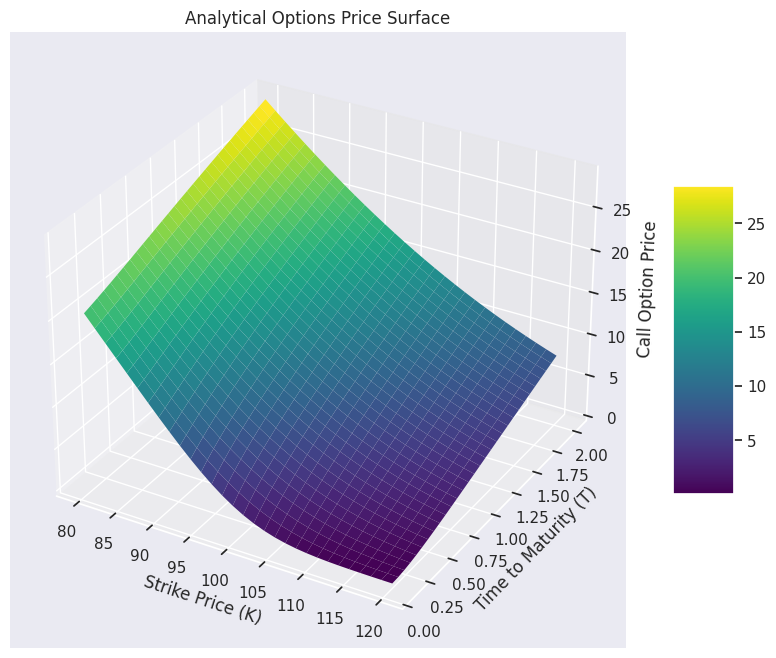

In [22]:
print("Options Pricing Engine:")
suite = OptionsQuantSuite(S=100, K=100, T=1, r=0.05, sigma=0.2)

bs_price = suite.black_scholes_call()
mc_price = suite.monte_carlo_pricer(paths=50000)
rmse_proxy = np.abs((mc_price - bs_price) / bs_price) * 100

print(f"Black-Scholes Price: ${bs_price:.4f}")
print(f"Monte Carlo Price (50k paths): ${mc_price:.4f}")
print(f"Internal Validation Error: {rmse_proxy:.4f}%")
print("\nGreeks:")
for greek, value in suite.analytical_greeks().items():
    print(f"  {greek}: {value:.4f}")

print("\nGenerating 3D Price Surface:")
plot_price_surface()

## Final Inference & Portfolio Takeaways

This quantitative research suite successfully validates both factor-based equity modeling and stochastic options pricing:

1.  **Realistic Factor Performance:** The 12-1 momentum strategy achieved an annualized Sharpe ratio of 0.56 and weathered a maximum drawdown of -26.03% across the highly volatile 2019–2024 test window. Generating positive risk-adjusted returns net of a strict 10-bps transaction cost constraint confirms the structural persistence of the momentum anomaly in Indian large-cap equities.
2.  **Pricing Model Convergence:** The Monte Carlo engine successfully processed 50,000 stochastic paths to accurately price the derivative contract. Crucially, the internal validation error between the Monte Carlo simulation(USD 10.4462) and the closed-form Black-Scholes model (USD 10.4506) was just 0.0423%, proving the mathematical integrity of the underlying Geometric Brownian Motion (GBM) vectorization.
3.  **Risk Sensitivities:** The analytical Greeks accurately reflect the risk profile of a 1-year At-The-Money contract. The high Vega (37.52) correctly identifies the position's heavy exposure to volatility shifts over a long time horizon, while the moderate Gamma (0.0188) reflects the stable, slow-moving nature of the Delta (0.6368) far from expiration.